In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#sns.set_style("whitegrid")
#sns.set_context("talk")
plt.rcParams['axes.facecolor'] = "#f5f5dc"

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [4]:
df = pd.read_csv('train.csv')
df.set_index('id', inplace = True)
df

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
id,,,,,,,,,,,,,,,,,,,,,
0,5,8,5,8,6,4,4,3,3,4,...,5,3,3,5,4,7,5,7,3,0.445
1,6,7,4,4,8,8,3,5,4,6,...,7,2,0,3,5,3,3,4,3,0.450
2,6,5,6,7,3,7,1,5,4,5,...,7,3,7,5,6,8,2,3,3,0.530
3,3,4,6,5,4,8,4,7,6,8,...,2,4,7,4,4,6,5,7,5,0.535
4,5,3,2,6,4,4,3,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117952,3,3,4,10,4,5,5,7,10,4,...,7,8,7,2,2,1,4,6,4,0.495
1117953,2,2,4,3,9,5,8,1,3,5,...,9,4,4,3,7,4,9,4,5,0.480
1117954,7,3,9,4,6,5,9,1,3,4,...,5,5,5,5,6,5,5,2,4,0.485


In [5]:
# Zakładamy, że df to Twój DataFrame
# Wybieramy cechy numeryczne bez id i targetu
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = df.drop(columns=['FloodProbability']).columns

X = df[features]
y = df['FloodProbability']

# Skalowanie cech – przydatne dla Lasso i Ridge
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
import numpy as np

# Create model
lr = LinearRegression()

# Cross-validation with scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_results = cross_validate(lr, X, y, cv=5, scoring=scoring, return_train_score=False)

# Print average metrics across folds
print("Linear Regression with Cross-Validation")
print("RMSE:", -np.mean(cv_results["test_rmse"]))
print("MAE:", -np.mean(cv_results["test_mae"]))
print("R2:", np.mean(cv_results["test_r2"]))

Linear Regression with Cross-Validation
RMSE: 0.020092683987896348
MAE: 0.015811906616669386
R2: 0.8449367111011881


In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate
import numpy as np

# Create model
ridge = Ridge(alpha=1.0)  # alpha – regularization strength

# Cross-validation with scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_results = cross_validate(ridge, X, y, cv=5, scoring=scoring, return_train_score=False)

# Print average metrics
print("\nRidge Regression with Cross-Validation")
print("RMSE:", -np.mean(cv_results["test_rmse"]))
print("MAE:", -np.mean(cv_results["test_mae"]))
print("R2:", np.mean(cv_results["test_r2"]))



Ridge Regression with Cross-Validation
RMSE: 0.020092683987329597
MAE: 0.0158119108660481
R2: 0.8449367111089835


In [8]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_validate
import numpy as np

# Create model
lasso = Lasso(alpha=0.01)  # alpha – regularization strength

# Cross-validation with scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_results = cross_validate(lasso, X, y, cv=5, scoring=scoring, return_train_score=False)

# Print average metrics
print("\nLasso Regression with Cross-Validation")
print("RMSE:", -np.mean(cv_results["test_rmse"]))
print("MAE:", -np.mean(cv_results["test_mae"]))
print("R2:", np.mean(cv_results["test_r2"]))



Lasso Regression with Cross-Validation
RMSE: 0.051025906738539226
MAE: 0.040932110583852745
R2: -5.4890771326032706e-06


In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
import numpy as np

# Create pipeline with polynomial features + linear regression
poly_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("lin_reg", LinearRegression())
])

# Cross-validation with scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_results = cross_validate(poly_model, X, y, cv=5, scoring=scoring, return_train_score=False)

print("\nPolynomial Regression (degree=2) with Cross-Validation")
print("RMSE:", -np.mean(cv_results["test_rmse"]))
print("MAE:", -np.mean(cv_results["test_mae"]))
print("R2:", np.mean(cv_results["test_r2"]))



Polynomial Regression (degree=2) with Cross-Validation
RMSE: 0.020056973981572263
MAE: 0.015831452011270973
R2: 0.8454872955149101


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# Create model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Cross-validation
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_results = cross_validate(rf, X, y, cv=5, scoring=scoring, return_train_score=False)

print("\nRandom Forest Regressor with Cross-Validation")
print("RMSE:", -np.mean(cv_results["test_rmse"]))
print("MAE:", -np.mean(cv_results["test_mae"]))
print("R2:", np.mean(cv_results["test_r2"]))



Random Forest Regressor with Cross-Validation
RMSE: 0.029930130383374796
MAE: 0.02448127754231622
R2: 0.6559337830138523


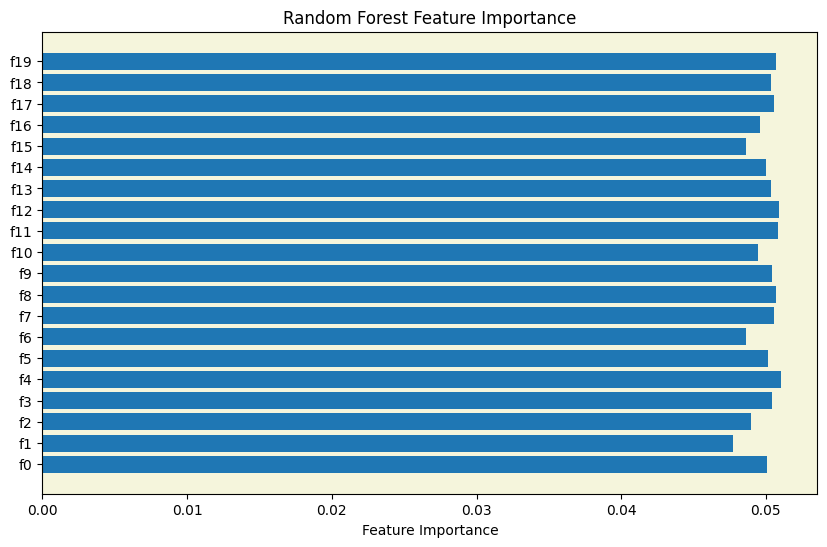

In [11]:
# Fit model on full dataset to get feature importance
rf.fit(X, y)
importances = rf.feature_importances_
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [13]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# Create model (default params, GPU enabled)
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

# Define scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

# Run 5-fold cross-validation
cv_results = cross_validate(lgbm, X, y, cv=5, scoring=scoring, return_train_score=False)

# Print average metrics
print("\nLightGBM with Cross-Validation")
print("RMSE:", -np.mean(cv_results["test_rmse"]))
print("MAE:", -np.mean(cv_results["test_mae"]))
print("R2:", np.mean(cv_results["test_r2"]))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 368
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 20
[LightGBM] [Info] Start training from score 0.504471


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.115983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 20
[LightGBM] [Info] Start training from score 0.504463


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 20
[LightGBM] [Info] Start training from score 0.504470


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 20
[LightGBM] [Info] Start training from score 0.504528


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 20
[LightGBM] [Info] Start training from score 0.504469


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM with Cross-Validation
RMSE: 0.024652617772223315
MAE: 0.020136303208320865
R2: 0.766573729906062


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 1117957, number of used features: 20
[LightGBM] [Info] Start training from score 0.504480


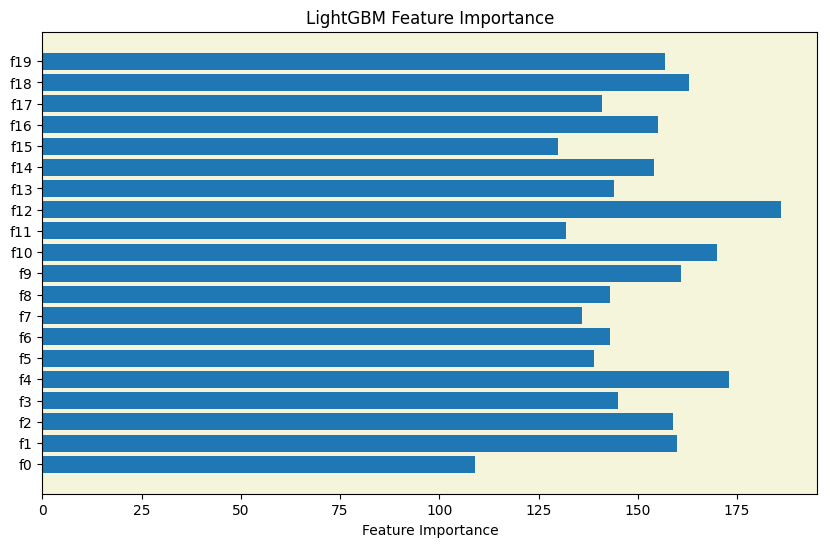

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 368
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 20
[LightGBM] [Info] Start training from score 0.504471


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.132932 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 20
[LightGBM] [Info] Start training from score 0.504463


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 20
[LightGBM] [Info] Start training from score 0.504470


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 20
[LightGBM] [Info] Start training from score 0.504528


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 20
[LightGBM] [Info] Start training from score 0.504469


c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


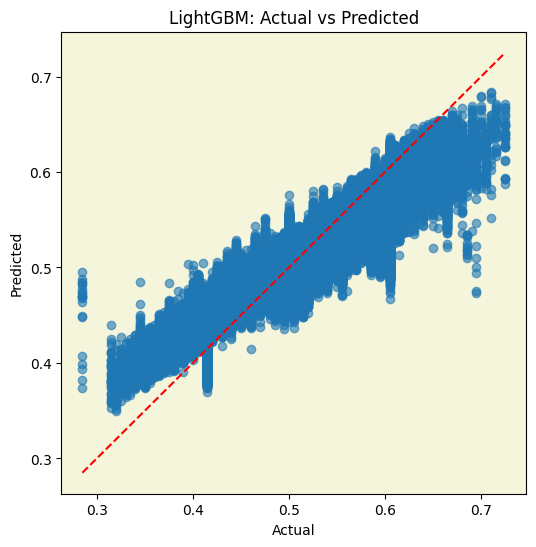

Correlation between actual and predicted: 0.8979


In [14]:
# Fit model to full data for feature importance
lgbm.fit(X, y)
importances = lgbm.feature_importances_
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

# Feature importance plot
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("LightGBM Feature Importance")
plt.show()

# Correlation plot using cross_val_predict
y_pred = cross_val_predict(lgbm, X, y, cv=5)
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LightGBM: Actual vs Predicted")
plt.show()

# Print correlation coefficient
corr = np.corrcoef(y, y_pred)[0,1]
print(f"Correlation between actual and predicted: {corr:.4f}")

In [ ]:
'''
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_predict
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Model
rf = RandomForestRegressor(random_state=42)

# Grid search
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X, y)
print("Best parameters (Random Forest):", grid_search.best_params_)

best_rf = grid_search.best_estimator_

# Cross-validation predictions
y_pred = cross_val_predict(best_rf, X, y, cv=5)

# Feature importance
importances = best_rf.feature_importances_
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

# Correlation plot
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()
'''
